**Purpose:** Export Reddit sentiment as a portfolio feature.

**Inputs:** `02_sentiment/reddit/h5a8a3d210b_full_run_data.parquet`, `as_feature_data.parquet`

**Outputs:** `as_feature_data.parquet`

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT


In [8]:
import pandas as pd
import json

df = pd.read_parquet(str(PROJECT_ROOT / "02_sentiment/reddit/h5a8a3d210b_full_run_data.parquet"))

df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)

for col in df.columns:
    if "label_" in col:
        try:
            df[col] = df[col].apply(json.loads)
        except Exception as e:
            print(f"Could not parse column {col} as JSON: {e}")

df.sample(3)

,subreddit,timestamp_utc,label_Information Technology,label_Health Care,label_Materials,label_Financials,label_Consumer Discretionary,label_Utilities,label_Communication Services,label_Real Estate,label_Consumer Staples,label_Energy,label_Industrials
879vsk,stocks,2018-03-26 15:16:37+00:00,"{'label': 'neutral', 'score': 0.828}","{'label': 'neutral', 'score': 0.996}","{'label': 'neutral', 'score': 0.998}","{'label': 'neutral', 'score': 0.966}","{'label': 'negative', 'score': 0.508}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 0.995}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.998}","{'label': 'neutral', 'score': 0.956}"
nkza6a,wallstreetbets,2021-05-25 20:29:45+00:00,"{'label': 'positive', 'score': 0.647}","{'label': 'neutral', 'score': 0.997}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.915}","{'label': 'neutral', 'score': 0.94}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 0.993}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.996}"
gk0g70,stocks,2020-05-15 02:12:34+00:00,"{'label': 'neutral', 'score': 0.975}","{'label': 'neutral', 'score': 0.966}","{'label': 'neutral', 'score': 0.995}","{'label': 'neutral', 'score': 0.949}","{'label': 'neutral', 'score': 0.784}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.993}","{'label': 'neutral', 'score': 0.995}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.98}"


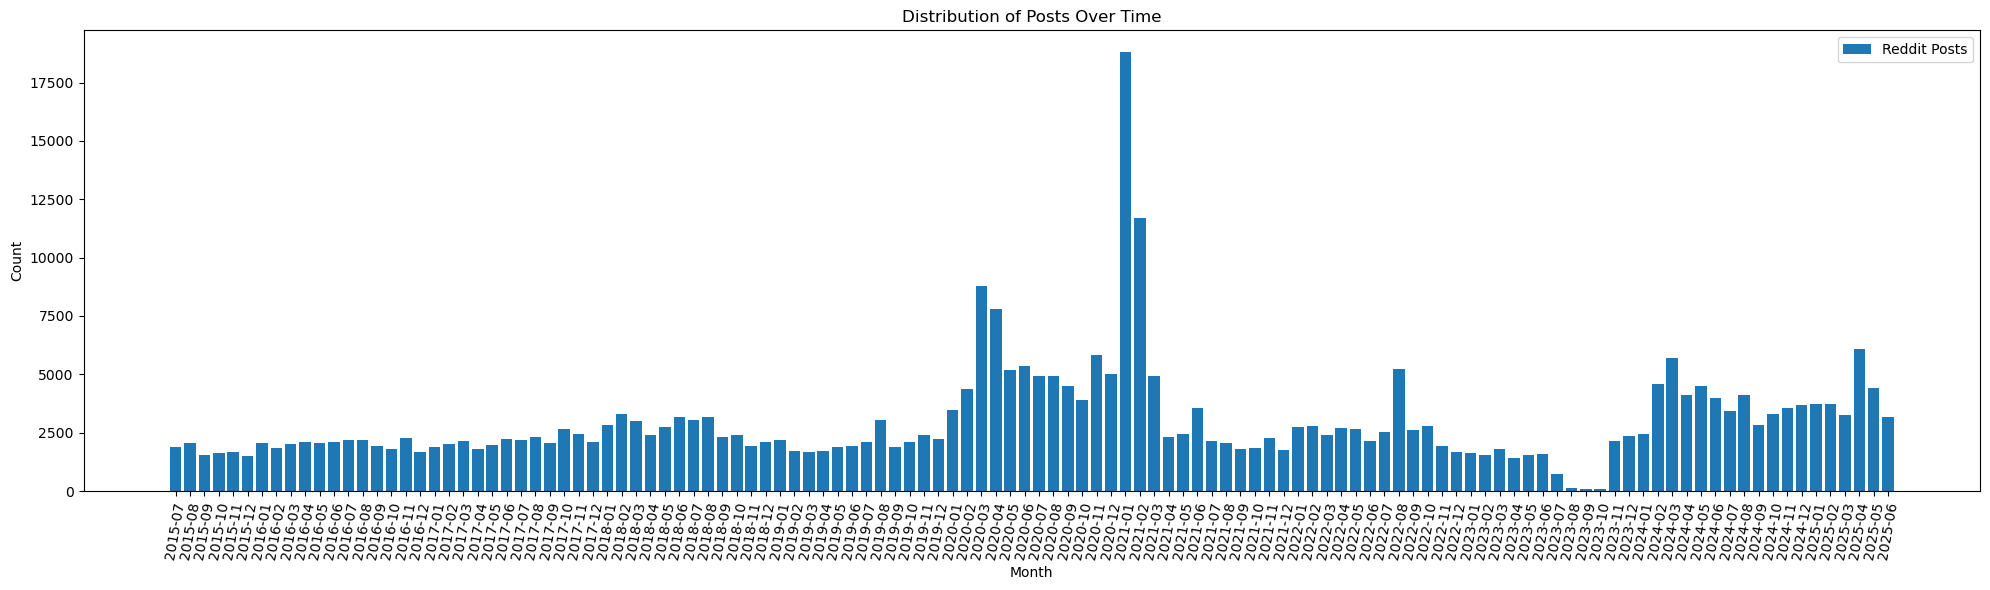

In [9]:
import matplotlib.pyplot as plt

posts_per_month = df.groupby(df['timestamp_utc'].dt.strftime('%Y-%m')).size()

plt.figure(figsize=(20, 6))
plt.bar(posts_per_month.keys(), posts_per_month.values, label="Reddit Posts")
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Distribution of Posts Over Time")
plt.xticks(rotation=80)
plt.legend()
plt.tight_layout()
plt.show()

mapping de dias -> before market open goes to the past day, else stays in the same day ; implies timezone handling: currently the timestamps are in UTC, and NYSE opens at 9.30am US/Eastern (https://www.nyse.com/trade/hours-calendars)

In [10]:
df['timestamp_et'] = df['timestamp_utc'].dt.tz_convert('America/New_York')

# Spell current day's date
df['date_et'] = df['timestamp_et'].dt.date

# Set day bucket based on time (pre-market goes to previous day, else stays in the same day)
def set_day_bucket(row):
    if row['timestamp_et'].time() < pd.to_datetime("09:30").time():
        return row['date_et'] - pd.Timedelta(days=1)
    else:
        return row['date_et']
df['day_bucket'] = df.apply(set_day_bucket, axis=1)

# Drop aux columns used for processing
df.drop(columns=['subreddit', 'timestamp_utc', 'timestamp_et', 'date_et'], inplace=True)

df.sample(3)

,label_Information Technology,label_Health Care,label_Materials,label_Financials,label_Consumer Discretionary,label_Utilities,label_Communication Services,label_Real Estate,label_Consumer Staples,label_Energy,label_Industrials,day_bucket
b8c6je,"{'label': 'neutral', 'score': 0.998}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.951}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 0.998}","{'label': 'neutral', 'score': 1.0}",2019-04-01
a9xwz9,"{'label': 'neutral', 'score': 0.995}","{'label': 'neutral', 'score': 0.998}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.953}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 1.0}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 1.0}",2018-12-26
117y2n6,"{'label': 'positive', 'score': 0.601}","{'label': 'neutral', 'score': 0.987}","{'label': 'neutral', 'score': 0.975}","{'label': 'neutral', 'score': 0.98}","{'label': 'neutral', 'score': 0.947}","{'label': 'neutral', 'score': 0.998}","{'label': 'neutral', 'score': 0.996}","{'label': 'neutral', 'score': 0.999}","{'label': 'neutral', 'score': 0.995}","{'label': 'neutral', 'score': 0.994}","{'label': 'neutral', 'score': 0.997}",2023-02-20


In [11]:
assets = ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']

sectors = {
    "label_Materials": "XLB",
    "label_Communication Services": "XLC",
    "label_Energy": "XLE",
    "label_Financials": "XLF",
    "label_Industrials": "XLI",
    "label_Information Technology": "XLK",
    "label_Consumer Staples": "XLP",
    "label_Real Estate": "XLRE",
    "label_Utilities": "XLU",
    "label_Health Care": "XLV",
    "label_Consumer Discretionary": "XLY"
}

sentiments = {
    "negative",
    "neutral",
    "positive"
}

In [12]:
data = {}

for i, row in df.iterrows():
    day = row['day_bucket']
    if day not in data:
        data[day] = {
            f"{asset}_reddit_sentiment_{sentiment}": [] for asset in assets for sentiment in sentiments
        }

    for sector in sectors.keys():
        sentiment = row[sector]["label"]
        prob = row[sector]["score"]

        key = f"{sectors[sector]}_reddit_sentiment_{sentiment}"
        data[day][key].append(prob)

data = pd.DataFrame.from_dict(data, orient='index')

problemas:


[ ] non trading days -> use lag and forget : up to 3 days before (longest non-trading period streak, based on our downloaded data)

[X] data structure -> < asset > _ reddit _ sentiment _ < sentiment > as column name and value being the list of classifications confidences for that day and that ETF

In [13]:
data

,XLB_reddit_sentiment_positive,XLB_reddit_sentiment_negative,XLB_reddit_sentiment_neutral,XLC_reddit_sentiment_positive,XLC_reddit_sentiment_negative,XLC_reddit_sentiment_neutral,XLE_reddit_sentiment_positive,XLE_reddit_sentiment_negative,XLE_reddit_sentiment_neutral,XLF_reddit_sentiment_positive,...,XLRE_reddit_sentiment_neutral,XLU_reddit_sentiment_positive,XLU_reddit_sentiment_negative,XLU_reddit_sentiment_neutral,XLV_reddit_sentiment_positive,XLV_reddit_sentiment_negative,XLV_reddit_sentiment_neutral,XLY_reddit_sentiment_positive,XLY_reddit_sentiment_negative,XLY_reddit_sentiment_neutral
2015-06-30,[],[],"[0.99, 0.999, 0.999, 0.991, 0.999, 0.998, 0.99...",[],[],"[0.994, 0.999, 1.0, 1.0, 0.999, 0.998, 0.999, ...",[],[],"[0.998, 0.999, 0.999, 0.955, 0.985, 0.999, 0.9...",[0.485],...,"[0.983, 1.0, 1.0, 0.999, 0.998, 0.999, 1.0, 1....",[],[],"[0.999, 1.0, 1.0, 0.998, 0.999, 1.0, 1.0, 1.0,...",[],[],"[0.994, 0.999, 1.0, 0.998, 0.996, 0.997, 0.998...",[],[],"[0.999, 0.996, 0.999, 0.997, 0.996, 0.993, 0.9..."
2015-07-01,[],[],"[1.0, 0.998, 1.0, 0.998, 0.993, 0.994, 0.999, ...",[],[],"[0.994, 0.998, 0.999, 0.937, 1.0, 0.981, 0.998...","[0.595, 0.74]","[0.858, 0.685, 0.958]","[0.999, 0.998, 0.999, 0.998, 0.992, 0.999, 0.9...",[],...,"[0.999, 0.997, 0.999, 0.999, 0.998, 0.993, 0.9...",[],[],"[1.0, 0.999, 1.0, 0.999, 0.997, 0.998, 0.995, ...","[0.959, 0.989, 0.996]",[0.96],"[0.991, 0.998, 0.998, 0.997, 0.988, 0.993, 0.9...","[0.666, 0.934]",[],"[0.392, 0.99, 0.996, 0.91, 0.993, 0.791, 0.995..."
2015-07-02,[],[],"[0.999, 0.998, 0.999, 1.0, 1.0, 0.998, 1.0, 0....",[],[0.526],"[0.962, 1.0, 0.999, 0.999, 1.0, 1.0, 0.952, 0....","[0.804, 0.767]",[],"[0.999, 0.999, 0.998, 0.999, 0.999, 0.999, 0.9...",[],...,"[0.999, 1.0, 0.999, 1.0, 1.0, 1.0, 1.0, 0.999,...",[],[],"[0.999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0...",[0.993],[],"[0.998, 0.999, 0.999, 1.0, 1.0, 0.998, 1.0, 0....","[0.963, 0.541]",[],"[0.899, 1.0, 1.0, 0.998, 0.992, 0.999, 0.859, ..."
2015-07-03,[],[],"[0.999, 0.999, 0.999, 0.999, 0.999, 0.998, 0.9...",[],[],"[0.998, 0.999, 0.999, 0.999, 0.999, 0.999, 0.9...",[0.684],[],"[0.999, 0.999, 0.997, 0.999, 0.998, 0.998, 0.9...",[],...,"[0.999, 0.999, 0.998, 1.0, 0.999, 1.0, 0.999, ...",[],[],"[1.0, 1.0, 0.999, 1.0, 1.0, 1.0, 0.999, 1.0, 1...",[],[],"[0.974, 0.998, 0.941, 0.998, 0.999, 0.999, 0.9...",[],[],"[0.998, 0.999, 0.981, 0.989, 0.999, 0.997, 0.6..."
2015-07-04,[],[],"[0.998, 0.987, 0.999, 0.992, 0.999, 0.957, 0.9...",[],[],"[0.998, 0.999, 0.999, 0.997, 0.991, 1.0, 1.0, ...",[0.864],[],"[0.999, 0.977, 0.999, 0.887, 0.997, 0.999, 0.9...",[],...,"[0.997, 0.979, 0.999, 0.998, 0.998, 0.999, 1.0...",[],[],"[0.999, 0.999, 1.0, 0.997, 0.999, 0.993, 1.0, ...",[],[],"[0.997, 0.995, 0.999, 0.999, 0.999, 0.996, 0.9...",[],[],"[0.999, 0.98, 0.992, 0.993, 0.788, 0.993, 0.99..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,"[0.951, 0.96]",[],"[0.999, 0.997, 0.997, 0.999, 0.999, 0.977, 0.9...",[],[],"[0.998, 0.999, 0.999, 0.998, 1.0, 0.958, 0.995...","[0.93, 0.96, 0.838]",[],"[0.999, 0.996, 0.872, 0.999, 0.998, 0.972, 0.9...",[0.986],...,"[1.0, 0.999, 0.999, 0.999, 1.0, 0.997, 0.998, ...",[],[],"[1.0, 0.999, 1.0, 1.0, 1.0, 0.998, 0.999, 0.99...",[],[],"[0.999, 0.998, 0.997, 0.998, 0.999, 0.977, 0.9...","[0.71, 0.868, 0.993]","[0.968, 0.893, 0.435]","[0.991, 0.971, 0.98, 0.999, 0.994, 0.988, 0.66..."
2025-06-27,"[0.916, 0.728]",[],"[0.999, 1.0, 0.999, 0.999, 0.996, 0.996, 1.0, ...",[],[],"[1.0, 1.0, 0.999, 0.94, 0.999, 0.989, 0.999, 0...","[0.814, 0.967]",[0.902],"[0.999, 0.999, 0.999, 0.998, 0.996, 0.997, 0.9...",[],...,"[1.0, 1.0, 0.999, 0.999, 0.999, 0.999, 1.0, 1....",[],[],"[1.0, 1.0, 1.0, 1.0, 1.0, 0.995, 1.0, 1.0, 0.9...","[0.708, 0.996]",[],"[0.999, 1.0, 0.999, 0.999, 0.997, 0.994, 1.0, ...","[0.948, 0.861, 0.878, 0.537]","[0.992, 0.983, 0.86]","[0.998, 0.965, 1.0, 0.842, 0.923, 0.952, 0.969..."
2025-06-28,[0.591],[],"[0.999, 0.996, 0.998, 0.999, 0.999, 0.994, 0.9...",[],[],"[0.989,

In [ ]:
# data.to_parquet("as_feature_data.parquet")

In [15]:
import pandas as pd

df = pd.read_parquet("as_feature_data.parquet")
df

,XLB_reddit_sentiment_positive,XLB_reddit_sentiment_negative,XLB_reddit_sentiment_neutral,XLC_reddit_sentiment_positive,XLC_reddit_sentiment_negative,XLC_reddit_sentiment_neutral,XLE_reddit_sentiment_positive,XLE_reddit_sentiment_negative,XLE_reddit_sentiment_neutral,XLF_reddit_sentiment_positive,...,XLRE_reddit_sentiment_neutral,XLU_reddit_sentiment_positive,XLU_reddit_sentiment_negative,XLU_reddit_sentiment_neutral,XLV_reddit_sentiment_positive,XLV_reddit_sentiment_negative,XLV_reddit_sentiment_neutral,XLY_reddit_sentiment_positive,XLY_reddit_sentiment_negative,XLY_reddit_sentiment_neutral
2015-06-30,[],[],"[0.99, 0.999, 0.999, 0.991, 0.999, 0.998, 0.99...",[],[],"[0.994, 0.999, 1.0, 1.0, 0.999, 0.998, 0.999, ...",[],[],"[0.998, 0.999, 0.999, 0.955, 0.985, 0.999, 0.9...",[0.485],...,"[0.983, 1.0, 1.0, 0.999, 0.998, 0.999, 1.0, 1....",[],[],"[0.999, 1.0, 1.0, 0.998, 0.999, 1.0, 1.0, 1.0,...",[],[],"[0.994, 0.999, 1.0, 0.998, 0.996, 0.997, 0.998...",[],[],"[0.999, 0.996, 0.999, 0.997, 0.996, 0.993, 0.9..."
2015-07-01,[],[],"[1.0, 0.998, 1.0, 0.998, 0.993, 0.994, 0.999, ...",[],[],"[0.994, 0.998, 0.999, 0.937, 1.0, 0.981, 0.998...","[0.595, 0.74]","[0.858, 0.685, 0.958]","[0.999, 0.998, 0.999, 0.998, 0.992, 0.999, 0.9...",[],...,"[0.999, 0.997, 0.999, 0.999, 0.998, 0.993, 0.9...",[],[],"[1.0, 0.999, 1.0, 0.999, 0.997, 0.998, 0.995, ...","[0.959, 0.989, 0.996]",[0.96],"[0.991, 0.998, 0.998, 0.997, 0.988, 0.993, 0.9...","[0.666, 0.934]",[],"[0.392, 0.99, 0.996, 0.91, 0.993, 0.791, 0.995..."
2015-07-02,[],[],"[0.999, 0.998, 0.999, 1.0, 1.0, 0.998, 1.0, 0....",[],[0.526],"[0.962, 1.0, 0.999, 0.999, 1.0, 1.0, 0.952, 0....","[0.804, 0.767]",[],"[0.999, 0.999, 0.998, 0.999, 0.999, 0.999, 0.9...",[],...,"[0.999, 1.0, 0.999, 1.0, 1.0, 1.0, 1.0, 0.999,...",[],[],"[0.999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0...",[0.993],[],"[0.998, 0.999, 0.999, 1.0, 1.0, 0.998, 1.0, 0....","[0.963, 0.541]",[],"[0.899, 1.0, 1.0, 0.998, 0.992, 0.999, 0.859, ..."
2015-07-03,[],[],"[0.999, 0.999, 0.999, 0.999, 0.999, 0.998, 0.9...",[],[],"[0.998, 0.999, 0.999, 0.999, 0.999, 0.999, 0.9...",[0.684],[],"[0.999, 0.999, 0.997, 0.999, 0.998, 0.998, 0.9...",[],...,"[0.999, 0.999, 0.998, 1.0, 0.999, 1.0, 0.999, ...",[],[],"[1.0, 1.0, 0.999, 1.0, 1.0, 1.0, 0.999, 1.0, 1...",[],[],"[0.974, 0.998, 0.941, 0.998, 0.999, 0.999, 0.9...",[],[],"[0.998, 0.999, 0.981, 0.989, 0.999, 0.997, 0.6..."
2015-07-04,[],[],"[0.998, 0.987, 0.999, 0.992, 0.999, 0.957, 0.9...",[],[],"[0.998, 0.999, 0.999, 0.997, 0.991, 1.0, 1.0, ...",[0.864],[],"[0.999, 0.977, 0.999, 0.887, 0.997, 0.999, 0.9...",[],...,"[0.997, 0.979, 0.999, 0.998, 0.998, 0.999, 1.0...",[],[],"[0.999, 0.999, 1.0, 0.997, 0.999, 0.993, 1.0, ...",[],[],"[0.997, 0.995, 0.999, 0.999, 0.999, 0.996, 0.9...",[],[],"[0.999, 0.98, 0.992, 0.993, 0.788, 0.993, 0.99..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,"[0.951, 0.96]",[],"[0.999, 0.997, 0.997, 0.999, 0.999, 0.977, 0.9...",[],[],"[0.998, 0.999, 0.999, 0.998, 1.0, 0.958, 0.995...","[0.93, 0.96, 0.838]",[],"[0.999, 0.996, 0.872, 0.999, 0.998, 0.972, 0.9...",[0.986],...,"[1.0, 0.999, 0.999, 0.999, 1.0, 0.997, 0.998, ...",[],[],"[1.0, 0.999, 1.0, 1.0, 1.0, 0.998, 0.999, 0.99...",[],[],"[0.999, 0.998, 0.997, 0.998, 0.999, 0.977, 0.9...","[0.71, 0.868, 0.993]","[0.968, 0.893, 0.435]","[0.991, 0.971, 0.98, 0.999, 0.994, 0.988, 0.66..."
2025-06-27,"[0.916, 0.728]",[],"[0.999, 1.0, 0.999, 0.999, 0.996, 0.996, 1.0, ...",[],[],"[1.0, 1.0, 0.999, 0.94, 0.999, 0.989, 0.999, 0...","[0.814, 0.967]",[0.902],"[0.999, 0.999, 0.999, 0.998, 0.996, 0.997, 0.9...",[],...,"[1.0, 1.0, 0.999, 0.999, 0.999, 0.999, 1.0, 1....",[],[],"[1.0, 1.0, 1.0, 1.0, 1.0, 0.995, 1.0, 1.0, 0.9...","[0.708, 0.996]",[],"[0.999, 1.0, 0.999, 0.999, 0.997, 0.994, 1.0, ...","[0.948, 0.861, 0.878, 0.537]","[0.992, 0.983, 0.86]","[0.998, 0.965, 1.0, 0.842, 0.923, 0.952, 0.969..."
2025-06-28,[0.591],[],"[0.999, 0.996, 0.998, 0.999, 0.999, 0.994, 0.9...",[],[],"[0.989,